In [1]:
# وارد کردن کتابخانه‌ها
import pandas as pd
import matplotlib.pyplot as pt
import seaborn as sb

# خواندن داده 
df = pd.read_csv("full_grouped.csv")

# تبدیل ستون از متن به تاریخ
df["Date"] = pd.to_datetime(df["Date"])

# مرتب‌ سازی بر اساس کشور و تاریخ
df = df.sort_values(["Country/Region", "Date"])
df = df.reset_index(drop=True)

# خواندن فایل‌ به صورت بخش‌های 100 هزار ردیفی
for chunk in pd.read_csv("full_grouped.csv", chunksize=100000):
    print(len(chunk))


35156


In [2]:
# تعداد سطر و ستون و نوع داده‌ها
print("Number of Rows and Columns:", df.shape)
print()
print(df.dtypes)

Number of Rows and Columns: (35156, 10)

Date              datetime64[us]
Country/Region               str
Confirmed                  int64
Deaths                     int64
Recovered                  int64
Active                     int64
New cases                  int64
New deaths                 int64
New recovered              int64
WHO Region                   str
dtype: object


In [3]:
# مقادیر گم‌شده و تکراری
print("Number of Missing:")
print(df.isna().sum())
print()

# سطرهایی که همه‌ی ستون‌هایشان تکراری است
print("Duplicates:", df.duplicated().sum())

Number of Missing:
Date              0
Country/Region    0
Confirmed         0
Deaths            0
Recovered         0
Active            0
New cases         0
New deaths        0
New recovered     0
WHO Region        0
dtype: int64

Duplicates: 0


In [4]:
# هر کشور در هر روز یک سطر دارد یعنی داده سری زمانی است
n_countries = df["Country/Region"].nunique()
n_days = df["Date"].nunique()
print()
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())


# داده‌ی آخرین روز
last_date = df["Date"].max()
last = df[df["Date"] == last_date].copy()
print("Number of Countries:", n_countries)
print("Number of Days:", n_days)
print()
print("Countries per WHO Region:")
print(last["WHO Region"].value_counts())


Date range: 2020-01-22 to 2020-07-27
Number of Countries: 187
Number of Days: 188

Countries per WHO Region:
WHO Region
Europe                   56
Africa                   48
Americas                 35
Eastern Mediterranean    22
Western Pacific          16
South-East Asia          10
Name: count, dtype: int64


In [5]:
#  توزیع متغیرها 
num_cols = ["Confirmed", "Deaths", "Recovered", "Active", "New cases", "New deaths", "New recovered"]
print(df[num_cols].describe())

          Confirmed         Deaths     Recovered        Active    New cases  \
count  3.515600e+04   35156.000000  3.515600e+04  3.515600e+04  35156.00000   
mean   2.356663e+04    1234.068239  1.104813e+04  1.128443e+04    469.36375   
std    1.499818e+05    7437.238354  6.454640e+04  8.997149e+04   3005.86754   
min    0.000000e+00       0.000000  0.000000e+00 -2.000000e+00      0.00000   
25%    1.000000e+00       0.000000  0.000000e+00  0.000000e+00      0.00000   
50%    2.500000e+02       4.000000  3.300000e+01  8.500000e+01      2.00000   
75%    3.640250e+03      78.250000  1.286250e+03  1.454000e+03     75.00000   
max    4.290259e+06  148011.000000  1.846641e+06  2.816444e+06  77255.00000   

         New deaths  New recovered  
count  35156.000000   35156.000000  
mean      18.603339     269.315593  
std      115.706351    2068.063852  
min    -1918.000000  -16298.000000  
25%        0.000000       0.000000  
50%        0.000000       0.000000  
75%        1.000000      20.0

In [6]:
# بررسی درست بودن داده‌ها

# Active باید برابر Confirmed - Deaths - Recovered باشد
calc_active = df["Confirmed"] - df["Deaths"] - df["Recovered"]
print("Rows where Active does not match the formula:", (df["Active"] != calc_active).sum())
print("Rows with negative Active:", (df["Active"] < 0).sum())

# مقادیر منفی در ستون‌های روزانه (معمولاً اصلاح گزارش‌ها هستند)
print("Negative New cases:", (df["New cases"] < 0).sum())
print("Negative New deaths:", (df["New deaths"] < 0).sum())
print("Negative New recovered:", (df["New recovered"] < 0).sum())

# بدترین موارد New deaths
print()
print(df.sort_values("New deaths").head(3)[["Date", "Country/Region", "Deaths", "New deaths"]])

# ستون Confirmed تجمعی است و نباید از یک روز به روز بعد کم شود
diff = df.groupby("Country/Region")["Confirmed"].diff()
print()
print("Days where Confirmed decreased:", (diff < 0).sum())

# کشورهایی که در آخرین روز Recovered صفر دارند ولی موارد زیادی دارند (مشکوک)
suspicious = last[(last["Recovered"] == 0) & (last["Confirmed"] > 100)]
print()
print("Countries with Recovered = 0 but Confirmed > 100:")
print(suspicious[["Country/Region", "Confirmed", "Deaths", "Recovered"]])

Rows where Active does not match the formula: 0
Rows with negative Active: 2
Negative New cases: 0
Negative New deaths: 38
Negative New recovered: 77

            Date Country/Region  Deaths  New deaths
29640 2020-05-25          Spain   26834       -1918
11586 2020-05-19         France   28025        -217
12300 2020-04-11        Germany    2736         -31

Days where Confirmed decreased: 33

Countries with Recovered = 0 but Confirmed > 100:
      Country/Region  Confirmed  Deaths  Recovered
6203          Canada     116458    8944          0
22183     Mozambique       1701      11          0
27823         Serbia      24141     543          0
30455         Sweden      79395    5700          0
30831          Syria        674      40          0


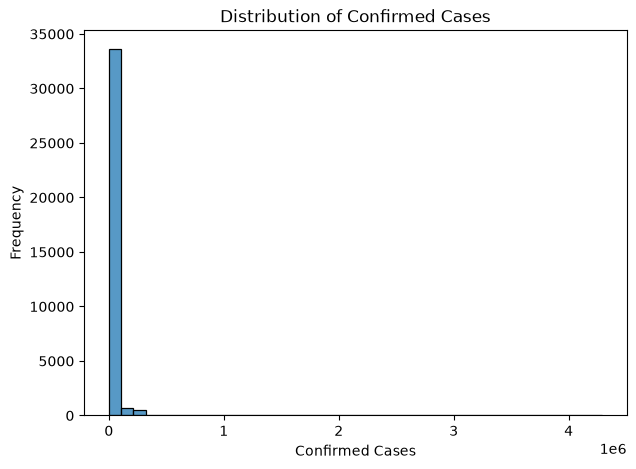

In [7]:
# بررسی توزیع Confirmed

pt.figure(figsize=(7, 5))

sb.histplot(
    data=df,
    x="Confirmed",
    bins=40
)

pt.title("Distribution of Confirmed Cases")
pt.xlabel("Confirmed Cases")
pt.ylabel("Frequency")

pt.show()

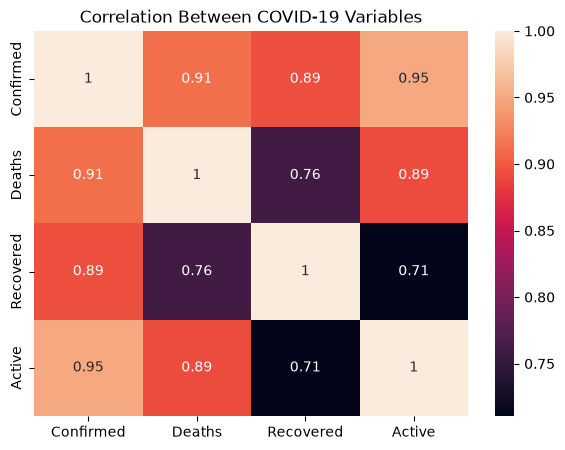

In [8]:
# بررسی رابطه بین متغیرهای مهم

corr_cols = [
    "Confirmed",
    "Deaths",
    "Recovered",
    "Active"
]

# محاسبه همبستگی بین متغیرها
correlation = df[corr_cols].corr()

pt.figure(figsize=(7, 5))

sb.heatmap(
    correlation,
    annot=True
)

pt.title("Correlation Between COVID-19 Variables")

pt.show()

In [9]:
# بررسی Outlier با روش IQR

outlier_results = {}

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_results[col] = len(outliers)

    print(f"\n{col}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("تعداد Outlier:", len(outliers))


Confirmed
Q1: 1.0
Q3: 3640.25
IQR: 3639.25
تعداد Outlier: 6313

Deaths
Q1: 0.0
Q3: 78.25
IQR: 78.25
تعداد Outlier: 6479

Recovered
Q1: 0.0
Q3: 1286.25
IQR: 1286.25
تعداد Outlier: 6217

Active
Q1: 0.0
Q3: 1454.0
IQR: 1454.0
تعداد Outlier: 6304

New cases
Q1: 0.0
Q3: 75.0
IQR: 75.0
تعداد Outlier: 6348

New deaths
Q1: 0.0
Q3: 1.0
IQR: 1.0
تعداد Outlier: 7368

New recovered
Q1: 0.0
Q3: 20.0
IQR: 20.0
تعداد Outlier: 6672


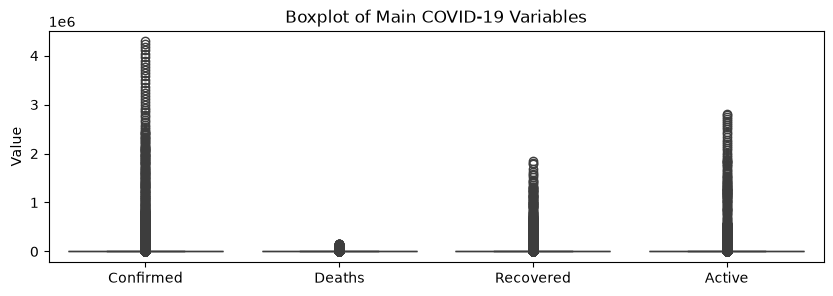

In [10]:
# نمایش Outlier با Boxplot

pt.figure(figsize=(10, 3))

sb.boxplot(
    data=df[
        [
            "Confirmed",
            "Deaths",
            "Recovered",
            "Active"
        ]
    ]
)

pt.title("Boxplot of Main COVID-19 Variables")
pt.ylabel("Value")

pt.show()